In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Show plots in the notebook
%matplotlib inline


In [ ]:
from google.colab import files

# This will prompt you to upload the file
uploaded = files.upload()


Saving aerofit_treadmill.csv to aerofit_treadmill (1).csv


In [ ]:
# Load dataset
df = pd.read_csv('aerofit_treadmill.csv')

# Show first few rows
df.head()


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Check data types
print("\nData types:\n", df.dtypes)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Dataset Shape: (180, 9)

Data types:
 Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object

Missing Values:
 Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64


In [ ]:
# Convert relevant columns to 'category'
categorical_cols = ['Product', 'Gender', 'MaritalStatus']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Check again
df.dtypes


,0
Product,category
Age,int64
Gender,category
Education,int64
MaritalStatus,category
Usage,int64
Fitness,int64
Income,int64
Miles,int64


In [ ]:
# Statistical summary for numerical columns
df.describe()


,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [ ]:
# Median values to compare with mean
df.median(numeric_only=True)


,0
Age,26.0
Education,16.0
Usage,3.0
Fitness,3.0
Income,50596.5
Miles,94.0


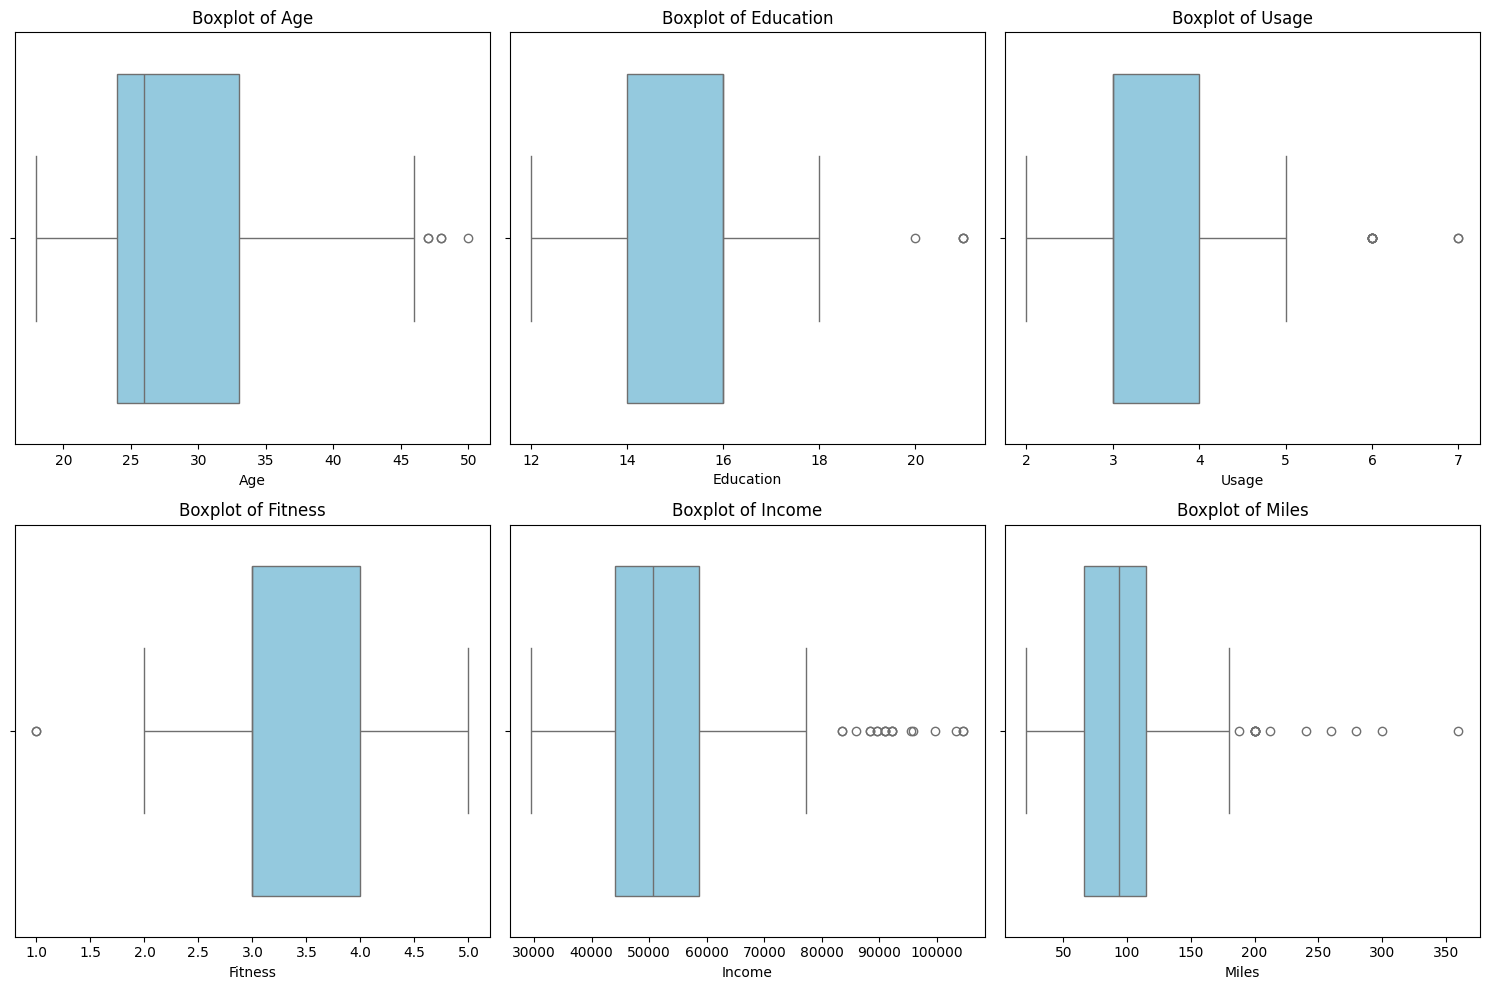

In [ ]:
# List of numerical columns
num_cols = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

# Plot boxplots for all numeric columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


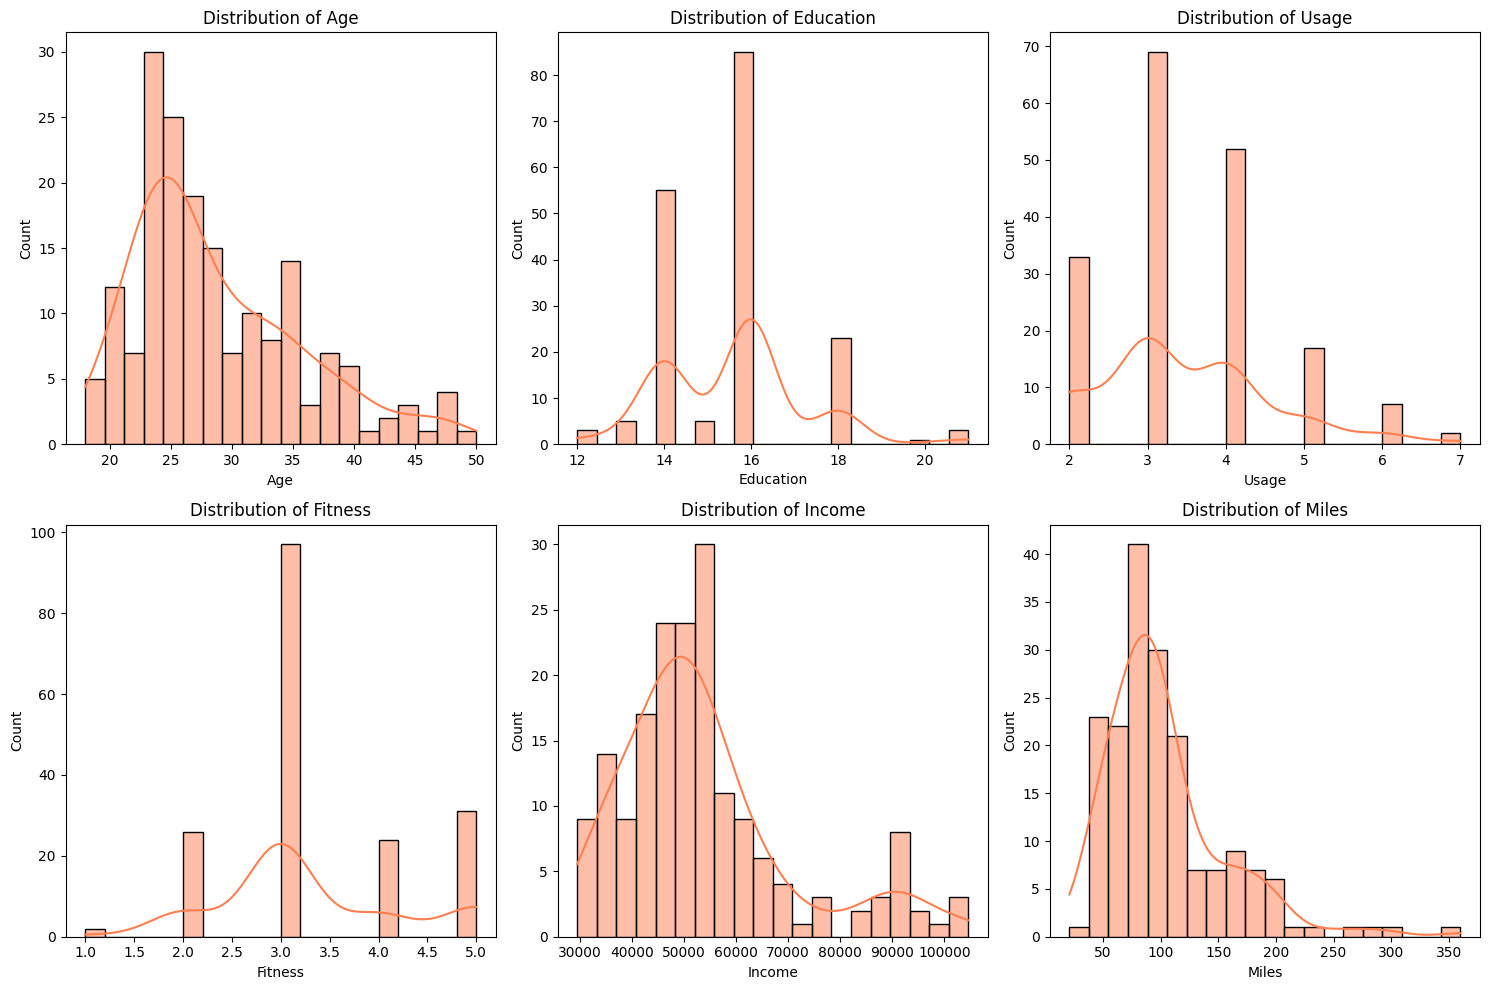

In [ ]:
# Plot distribution of continuous variables
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='coral')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


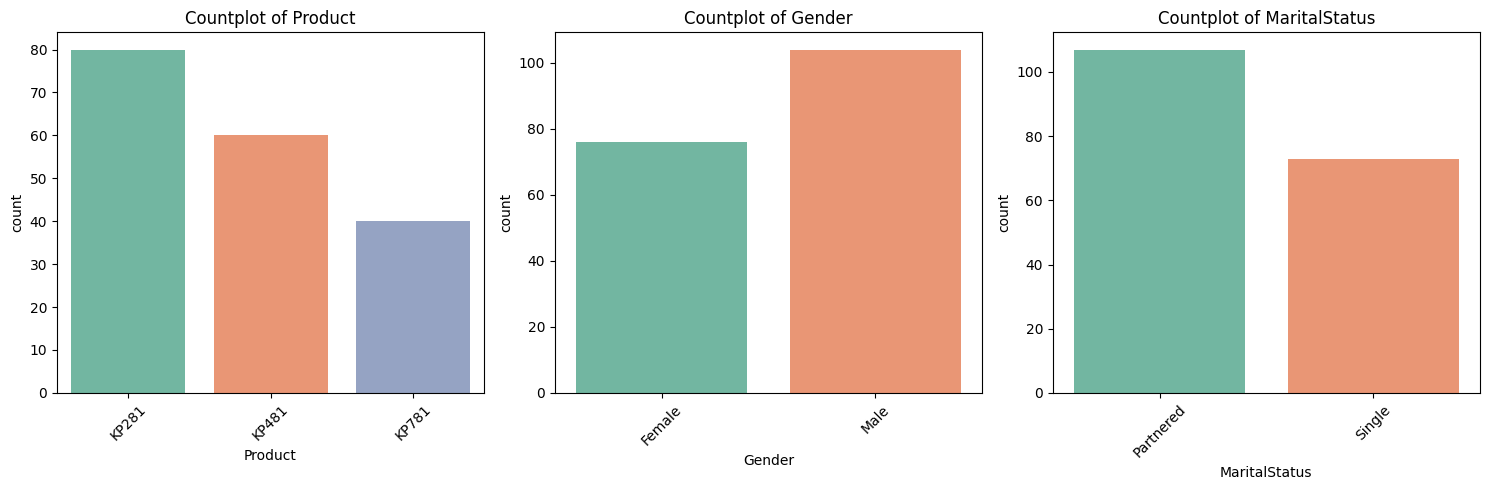

In [ ]:
# Plot countplots for categorical features without warning
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

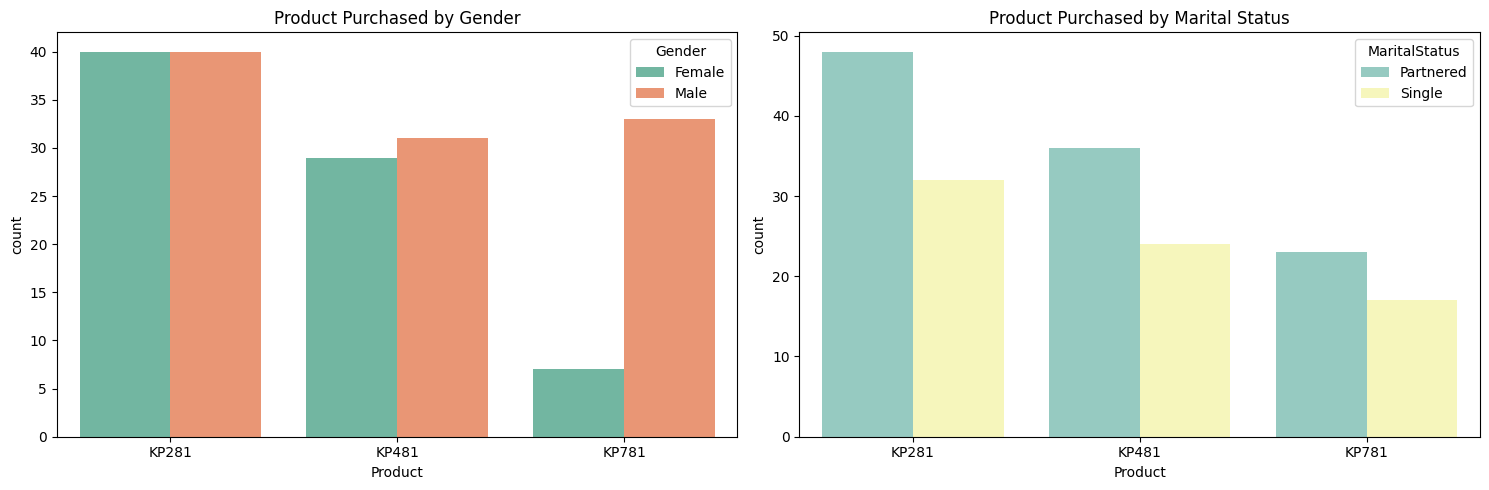

In [ ]:
plt.figure(figsize=(15, 5))

# Gender vs Product
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Product', hue='Gender', palette='Set2')
plt.title('Product Purchased by Gender')

# Marital Status vs Product
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Product', hue='MaritalStatus', palette='Set3')
plt.title('Product Purchased by Marital Status')

plt.tight_layout()
plt.show()


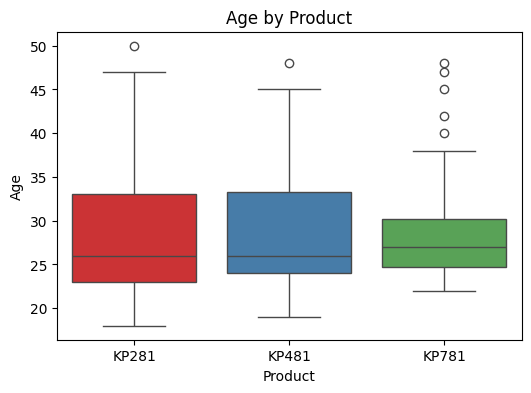

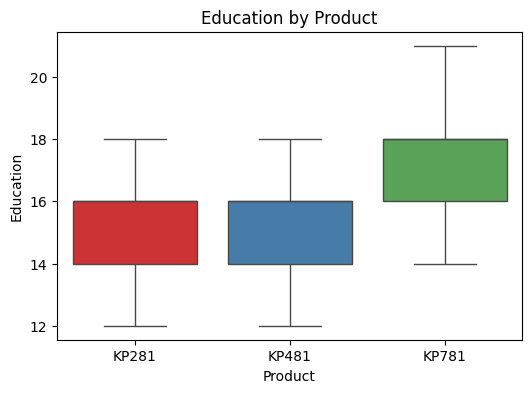

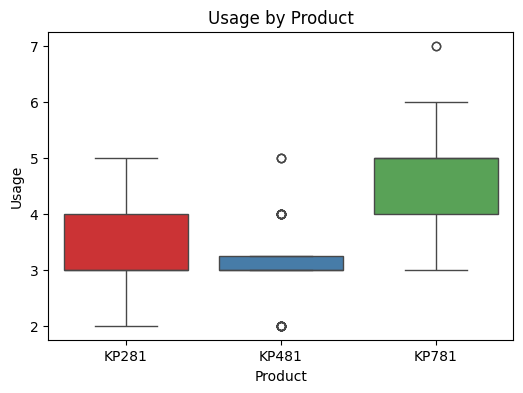

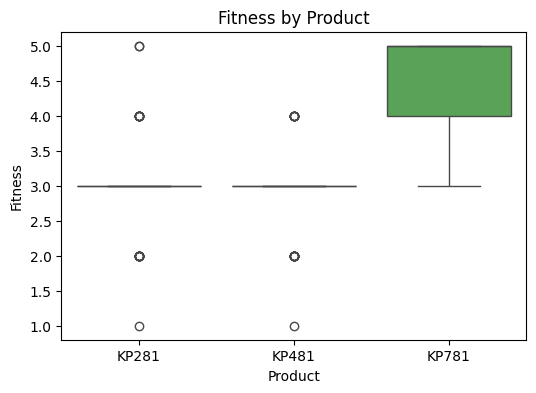

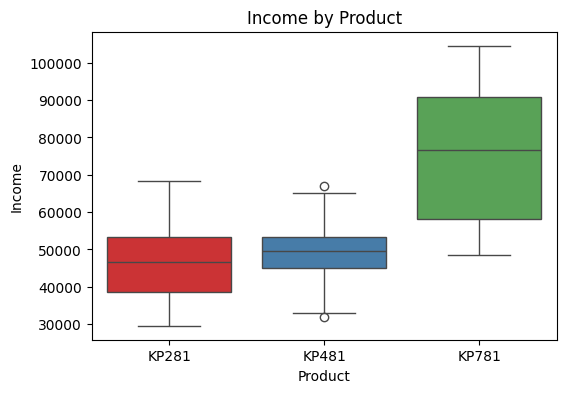

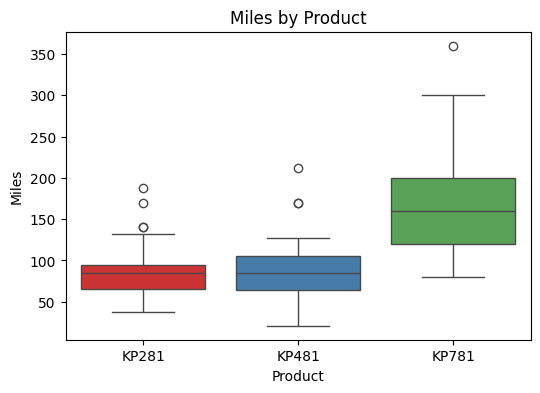

In [ ]:
# Step 7B: Boxplots of numerical columns by Product
num_cols = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='Product', y=col, hue='Product', palette='Set1', legend=False)
    plt.title(f'{col} by Product')
    plt.show()


In [ ]:
# Marginal Probability of Product
product_prob = df['Product'].value_counts(normalize=True)
print("Marginal Probability of each Product:\n", product_prob)


Marginal Probability of each Product:
 Product
KP281    0.444444
KP481    0.333333
KP781    0.222222
Name: proportion, dtype: float64


In [ ]:
# Conditional Probability of Product by Gender
cond_prob_gender = pd.crosstab(df['Gender'], df['Product'], normalize='index')
print("\nConditional Probability of Product by Gender:\n", cond_prob_gender)



Conditional Probability of Product by Gender:
 Product     KP281     KP481     KP781
Gender                               
Female   0.526316  0.381579  0.092105
Male     0.384615  0.298077  0.317308


In [ ]:
# Conditional Probability of Product by MaritalStatus
cond_prob_married = pd.crosstab(df['MaritalStatus'], df['Product'], normalize='index')
print("\nConditional Probability of Product by Marital Status:\n", cond_prob_married)



Conditional Probability of Product by Marital Status:
 Product           KP281     KP481     KP781
MaritalStatus                              
Partnered      0.448598  0.336449  0.214953
Single         0.438356  0.328767  0.232877


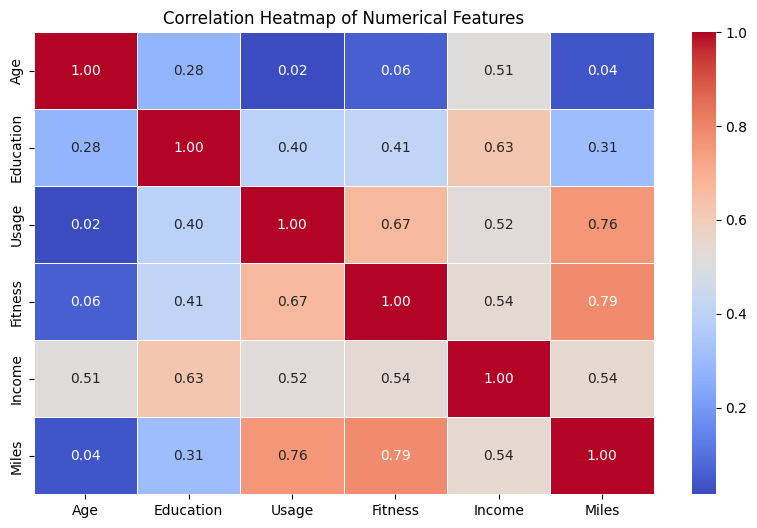

In [ ]:
# Select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


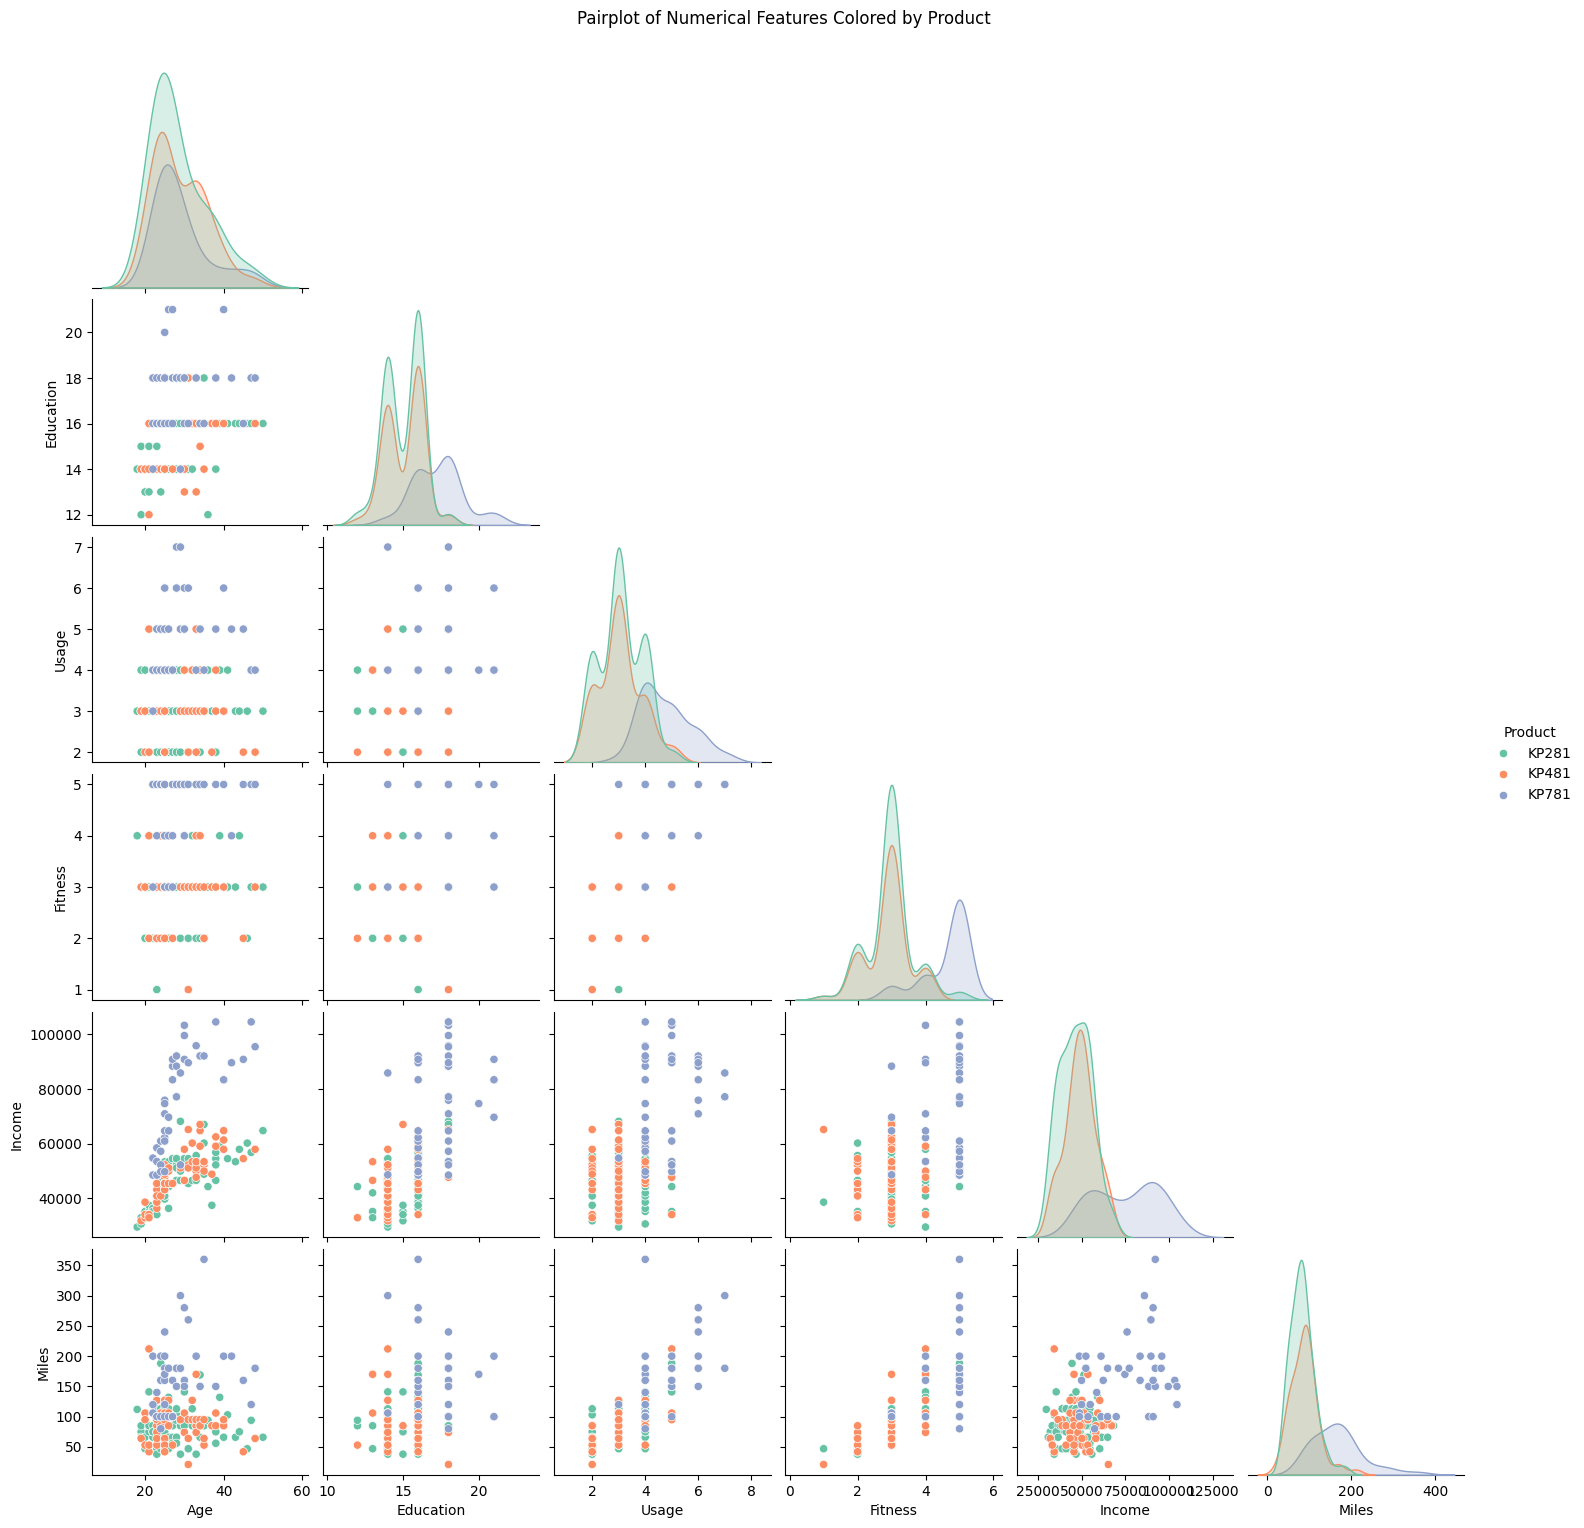

In [ ]:
# Plot pairplot
sns.pairplot(df, hue='Product', corner=True, diag_kind='kde', palette='Set2')
plt.suptitle("Pairplot of Numerical Features Colored by Product", y=1.02)
plt.show()


In [ ]:
# Marginal probability of each product
product_counts = df['Product'].value_counts(normalize=True)  # normalize=True gives proportion
product_probabilities = product_counts.rename_axis('Product').reset_index(name='Probability')

print("Marginal Probability of each Treadmill Product:")
print(product_probabilities)


Marginal Probability of each Treadmill Product:
  Product  Probability
0   KP281     0.444444
1   KP481     0.333333
2   KP781     0.222222


In [ ]:
# Conditional probability of Product given Gender
product_gender = pd.crosstab(df['Gender'], df['Product'], normalize='index')

print("Conditional Probability (Product | Gender):")
print(product_gender)


Conditional Probability (Product | Gender):
Product     KP281     KP481     KP781
Gender                               
Female   0.526316  0.381579  0.092105
Male     0.384615  0.298077  0.317308


In [ ]:
# Product by MaritalStatus
product_marital = pd.crosstab(df['MaritalStatus'], df['Product'], normalize='index')
print("Conditional Probability (Product | MaritalStatus):")
print(product_marital)


Conditional Probability (Product | MaritalStatus):
Product           KP281     KP481     KP781
MaritalStatus                              
Partnered      0.448598  0.336449  0.214953
Single         0.438356  0.328767  0.232877


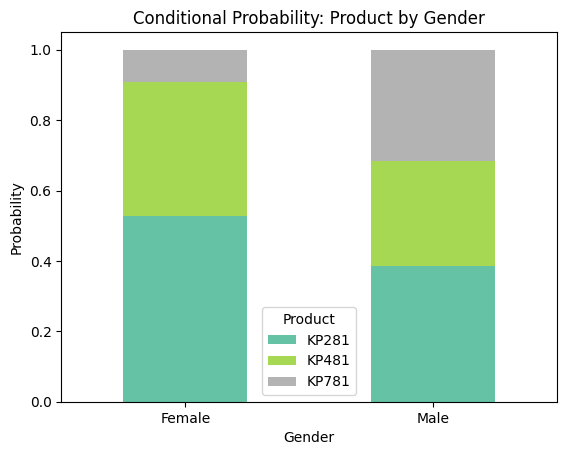

In [ ]:
# Bar plot for conditional probability of Product given Gender
product_gender.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Conditional Probability: Product by Gender')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.legend(title='Product')
plt.show()


In [ ]:
# Mean of numerical attributes grouped by product
profile_summary = df.groupby('Product')[['Age', 'Income', 'Miles', 'Usage', 'Fitness']].mean().round(2)
print("Customer Profile Summary by Product:")
print(profile_summary)
profile_summary = df.groupby('Product', observed=False)[['Age', 'Income', 'Miles', 'Usage', 'Fitness']].mean().round(2)


Customer Profile Summary by Product:
           Age    Income   Miles  Usage  Fitness
Product                                         
KP281    28.55  46418.02   82.79   3.09     2.96
KP481    28.90  48973.65   87.93   3.07     2.90
KP781    29.10  75441.58  166.90   4.78     4.62


<ipython-input-81-13882ac59ef8>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile_summary = df.groupby('Product')[['Age', 'Income', 'Miles', 'Usage', 'Fitness']].mean().round(2)


In [ ]:
# Marginal probabilities of product purchase
product_counts = df['Product'].value_counts(normalize=True).round(3) * 100
print("Marginal Probability (in %):\n")
print(product_counts)


Marginal Probability (in %):

Product
KP281    44.4
KP481    33.3
KP781    22.2
Name: proportion, dtype: float64


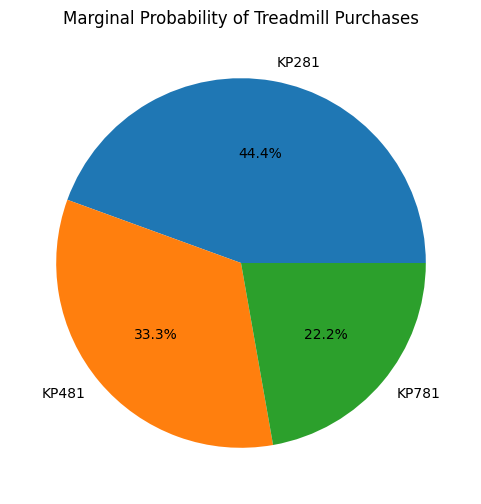

In [ ]:
product_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), title='Marginal Probability of Treadmill Purchases')
plt.ylabel('')
plt.show()


In [ ]:
# Conditional probability: Product vs Gender
product_gender_prob = pd.crosstab(df['Gender'], df['Product'], normalize='index').round(3) * 100
print("Conditional Probability (Product given Gender):\n")
print(product_gender_prob)


Conditional Probability (Product given Gender):

Product  KP281  KP481  KP781
Gender                      
Female    52.6   38.2    9.2
Male      38.5   29.8   31.7


In [ ]:
# Product given Fitness Level
product_fitness_prob = pd.crosstab(df['Fitness'], df['Product'], normalize='index').round(2) * 100
print("Conditional Probability (Product given Fitness):\n")
print(product_fitness_prob)


Conditional Probability (Product given Fitness):

Product  KP281  KP481  KP781
Fitness                     
1         50.0   50.0    0.0
2         54.0   46.0    0.0
3         56.0   40.0    4.0
4         38.0   33.0   29.0
5          6.0    0.0   94.0


## **Actionable Insights & Recommendations**

**1. Customer Distribution:**

*  KP281 is purchased by the highest number of customers, indicating it's popular—possibly due to affordability.

* KP781, despite being premium-priced, is often chosen by higher-income and more fit customers.

**2. Age & Income Insights:**

* KP781 buyers are typically older and have higher incomes.

* KP281 is favored by younger individuals or those with lower income brackets.

**3. Usage & Fitness Trends:**

* KP781 buyers tend to use the treadmill more frequently and rate their fitness level higher.

* KP281 users often have lower fitness levels and use the treadmill fewer times a week.

**4. Gender & Marital Status:**

* Males slightly prefer KP781, while KP281 is chosen equally by both genders.

* Partnered individuals tend to prefer mid-range KP481.

**5. Miles Expected per Week:**

* Higher mileage expectations are associated with KP781, aligning with its advanced features.



**Recommendations:**
* Offer Tiered Recommendation System: Suggest treadmills based on age, income, and fitness level during purchase. E.g., show KP781 for older, high-income users.

* Personalize Marketing: Target young, budget-conscious customers with ads for KP281 and fitness enthusiasts with KP781.

* Bundle and Upsell: For KP281 buyers, offer upgrade options or fitness accessories to increase revenue.

* Highlight Product Value: Educate potential KP481 customers on its balance between price and performance—can attract users sitting between KP281 and KP781.

* Improve Cross-Selling: Suggest training plans or diet guides for KP281 users with low fitness scores to improve customer experience and loyalty.